In [ ]:
# Sales Data Analysis Project

In [ ]:
# What is Sales Data Analysis?
# Sales Data Analysis is the process of examining sales data to extract meaningful insights about business performance, customer behavior, 
# and market trends. It involves collecting, cleaning, analyzing, and visualizing sales data to support data-driven decision making.


#This project involves analyzing sales data to extract meaningful business insights. 
# We'll explore patterns, trends, and relationships in the data to help make data-driven decisions. The analysis will cover:
# Data Exploration: Understanding the structure and quality of the dataset
# Sales Performance Analysis: Revenue trends, best-selling products, peak sales periods
# Geographical Analysis: Sales distribution across cities
# Time-based Analysis: Hourly, daily, and monthly sales patterns
# Customer Behavior: Purchase patterns and product preferences
# Business Insights: Recommendations based on data findings

In [4]:
# 1: Import Necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('fivethirtyeight')
sns.set_palette("Set2")

# pandas for data manipulation and analysis
# numpy for numerical operations
# matplotlib and seaborn for data visualization
# datetime for handling date-time data
# warnings to suppress unnecessary warnings

In [5]:
# 2: Load and Explore the Data

# Load the dataset
df = pd.read_csv('Sales Data.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


# This loads the CSV file and shows the structure of our dataset.

Dataset Shape: (185950, 11)

First 5 rows:


,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12


In [6]:
# Check dataset information
print("Dataset Info:")
df.info()

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check basic statistics
print("\nBasic Statistics:")
df.describe()

# info() shows data types and memory usage
# isnull().sum() checks for missing values
# describe() provides statistical summary of numerical columns

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        185950 non-null  int64  
 1   Order ID          185950 non-null  int64  
 2   Product           185950 non-null  object 
 3   Quantity Ordered  185950 non-null  int64  
 4   Price Each        185950 non-null  float64
 5   Order Date        185950 non-null  object 
 6   Purchase Address  185950 non-null  object 
 7   Month             185950 non-null  int64  
 8   Sales             185950 non-null  float64
 9   City              185950 non-null  object 
 10  Hour              185950 non-null  int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 15.6+ MB

Missing Values:
Unnamed: 0          0
Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
Month            

,Unnamed: 0,Order ID,Quantity Ordered,Price Each,Month,Sales,Hour
count,185950.000000,185950.000000,185950.000000,185950.000000,185950.000000,185950.000000,185950.000000
mean,8340.388475,230417.569379,1.124383,184.399735,7.059140,185.490917,14.413305
std,5450.554093,51512.737110,0.442793,332.731330,3.502996,332.919771,5.423416
min,0.000000,141234.000000,1.000000,2.990000,1.000000,2.990000,0.000000
25%,3894.000000,185831.250000,1.000000,11.950000,4.000000,11.950000,11.000000
50%,7786.000000,230367.500000,1.000000,14.950000,7.000000,14.950000,15.000000
75%,11872.000000,275035.750000,1.000000,150.000000,10.000000,150.000000,19.000000
max,25116.000000,319670.000000,9.000000,1700.000000,12.000000,3400.000000,23.000000


In [7]:
# 3: Data Cleaning and Preparation

# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Convert Order Date to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract additional time features
df['Day'] = df['Order Date'].dt.day
df['Day_of_Week'] = df['Order Date'].dt.day_name()
df['Month_Name'] = df['Order Date'].dt.month_name()

# Check the updated dataframe
df[['Order Date', 'Day', 'Day_of_Week', 'Month_Name']].head()


# We convert the date column to proper datetime format
# Extract day, day of week, and month name for time-based analysis
# This enhances our ability to analyze temporal patterns

Duplicate rows: 0


,Order Date,Day,Day_of_Week,Month_Name
0,2019-12-30 00:01:00,30,Monday,December
1,2019-12-29 07:03:00,29,Sunday,December
2,2019-12-12 18:21:00,12,Thursday,December
3,2019-12-22 15:13:00,22,Sunday,December
4,2019-12-18 12:38:00,18,Wednesday,December


Total Sales: $34,492,035.97
Total Orders: 178437
Average Order Value: $193.30


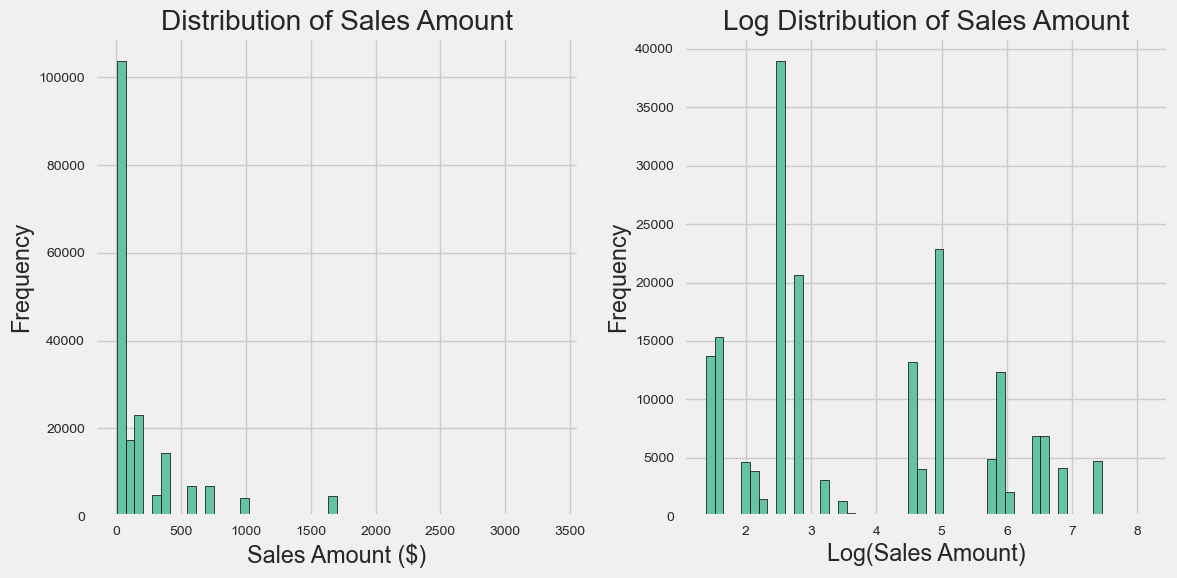

In [8]:
# 4: Exploratory Data Analysis (EDA)
     # 4.1 Overall Sales Analysis

# Total sales metrics
total_sales = df['Sales'].sum()
total_orders = df['Order ID'].nunique()
average_order_value = total_sales / total_orders

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Average Order Value: ${average_order_value:.2f}")

# Sales distribution
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
df['Sales'].hist(bins=50, edgecolor='black')
plt.title('Distribution of Sales Amount')
plt.xlabel('Sales Amount ($)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
# Log transform for better visualization of skewed data
np.log1p(df['Sales']).hist(bins=50, edgecolor='black')
plt.title('Log Distribution of Sales Amount')
plt.xlabel('Log(Sales Amount)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


# Calculate key business metrics
# Visualize sales distribution to understand spending patterns
# Log transformation helps visualize skewed data better


Top 10 Products by Revenue:
                                 Sales  Quantity Ordered  Order Count
Product                                                              
Macbook Pro Laptop          8037600.00              4728         4724
iPhone                      4794300.00              6849         6842
ThinkPad Laptop             4129958.70              4130         4128
Google Phone                3319200.00              5532         5525
27in 4K Gaming Monitor      2435097.56              6244         6230
34in Ultrawide Monitor      2355558.01              6199         6181
Apple Airpods Headphones    2349150.00             15661        15549
Flatscreen TV               1445700.00              4819         4800
Bose SoundSport Headphones  1345565.43             13457        13325
27in FHD Monitor            1132424.50              7550         7507


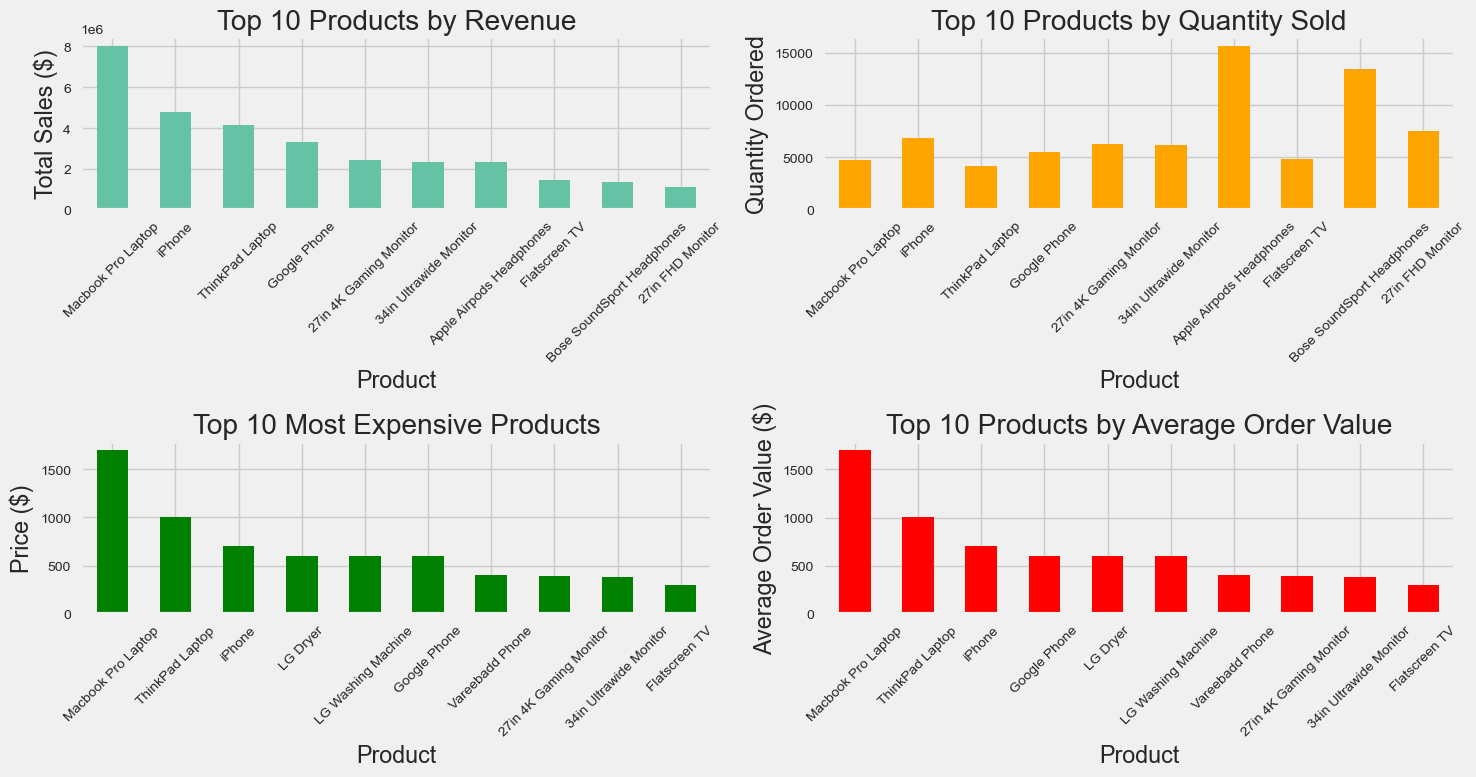

In [9]:
# 4.2 Sales by Product Analysis

# Top selling products by revenue
product_sales = df.groupby('Product').agg({
    'Sales': 'sum',
    'Quantity Ordered': 'sum',
    'Order ID': 'count'
}).rename(columns={'Order ID': 'Order Count'})

product_sales = product_sales.sort_values('Sales', ascending=False)

print("Top 10 Products by Revenue:")
print(product_sales.head(10))

# Visualization
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
product_sales.head(10)['Sales'].plot(kind='bar')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
product_sales.head(10)['Quantity Ordered'].plot(kind='bar', color='orange')
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Product')
plt.ylabel('Quantity Ordered')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
# Price distribution of products
df.groupby('Product')['Price Each'].first().sort_values(ascending=False).head(10).plot(kind='bar', color='green')
plt.title('Top 10 Most Expensive Products')
plt.xlabel('Product')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)

plt.subplot(2, 2, 4)
# Average order value by product
(df.groupby('Product')['Sales'].sum() / df.groupby('Product')['Order ID'].nunique()).sort_values(ascending=False).head(10).plot(kind='bar', color='red')
plt.title('Top 10 Products by Average Order Value')
plt.xlabel('Product')
plt.ylabel('Average Order Value ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# Group data by product to analyze performance
# Calculate revenue, quantity sold, and order count for each product
# Visualize different aspects of product performance

Sales by City:
                    Sales  Order Count  Quantity Ordered
City                                                    
San Francisco  8262203.91        44732             50239
Los Angeles    5452570.80        29605             33289
New York City  4664317.43        24876             27932
Boston         3661642.01        19934             22528
Atlanta        2795498.58        14881             16602
Dallas         2767975.40        14820             16730
Seattle        2747755.48        14732             16553
Portland       2320490.61        12465             14053
Austin         1819581.75         9905             11153


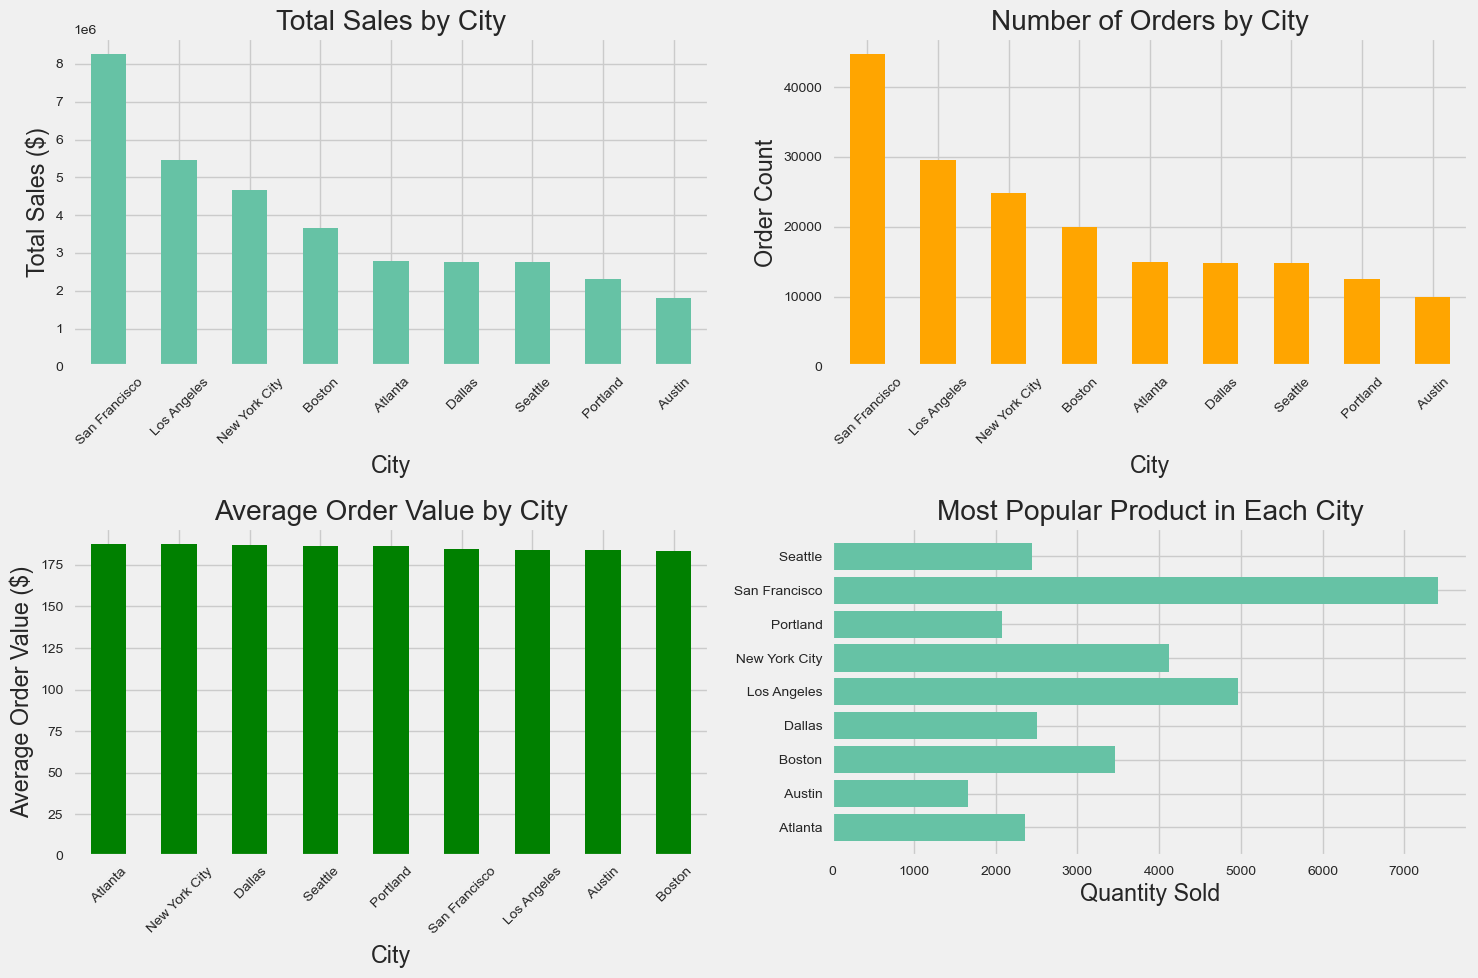

In [10]:
# 4.3 Sales by City Analysis

# Sales by city
city_sales = df.groupby('City').agg({
    'Sales': 'sum',
    'Order ID': 'count',
    'Quantity Ordered': 'sum'
}).rename(columns={'Order ID': 'Order Count'}).sort_values('Sales', ascending=False)

print("Sales by City:")
print(city_sales)

# Visualization
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
city_sales['Sales'].plot(kind='bar')
plt.title('Total Sales by City')
plt.xlabel('City')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
city_sales['Order Count'].plot(kind='bar', color='orange')
plt.title('Number of Orders by City')
plt.xlabel('City')
plt.ylabel('Order Count')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
# Average order value by city
avg_order_city = city_sales['Sales'] / city_sales['Order Count']
avg_order_city.sort_values(ascending=False).plot(kind='bar', color='green')
plt.title('Average Order Value by City')
plt.xlabel('City')
plt.ylabel('Average Order Value ($)')
plt.xticks(rotation=45)

plt.subplot(2, 2, 4)
# Popular products by city
city_product = df.groupby(['City', 'Product'])['Quantity Ordered'].sum().reset_index()
top_products_by_city = city_product.loc[city_product.groupby('City')['Quantity Ordered'].idxmax()]

plt.barh(top_products_by_city['City'], top_products_by_city['Quantity Ordered'])
plt.title('Most Popular Product in Each City')
plt.xlabel('Quantity Sold')
plt.tight_layout()
plt.show()




# Analyze sales performance across different cities
# Compare order volumes and average spending
# Identify most popular products in each location

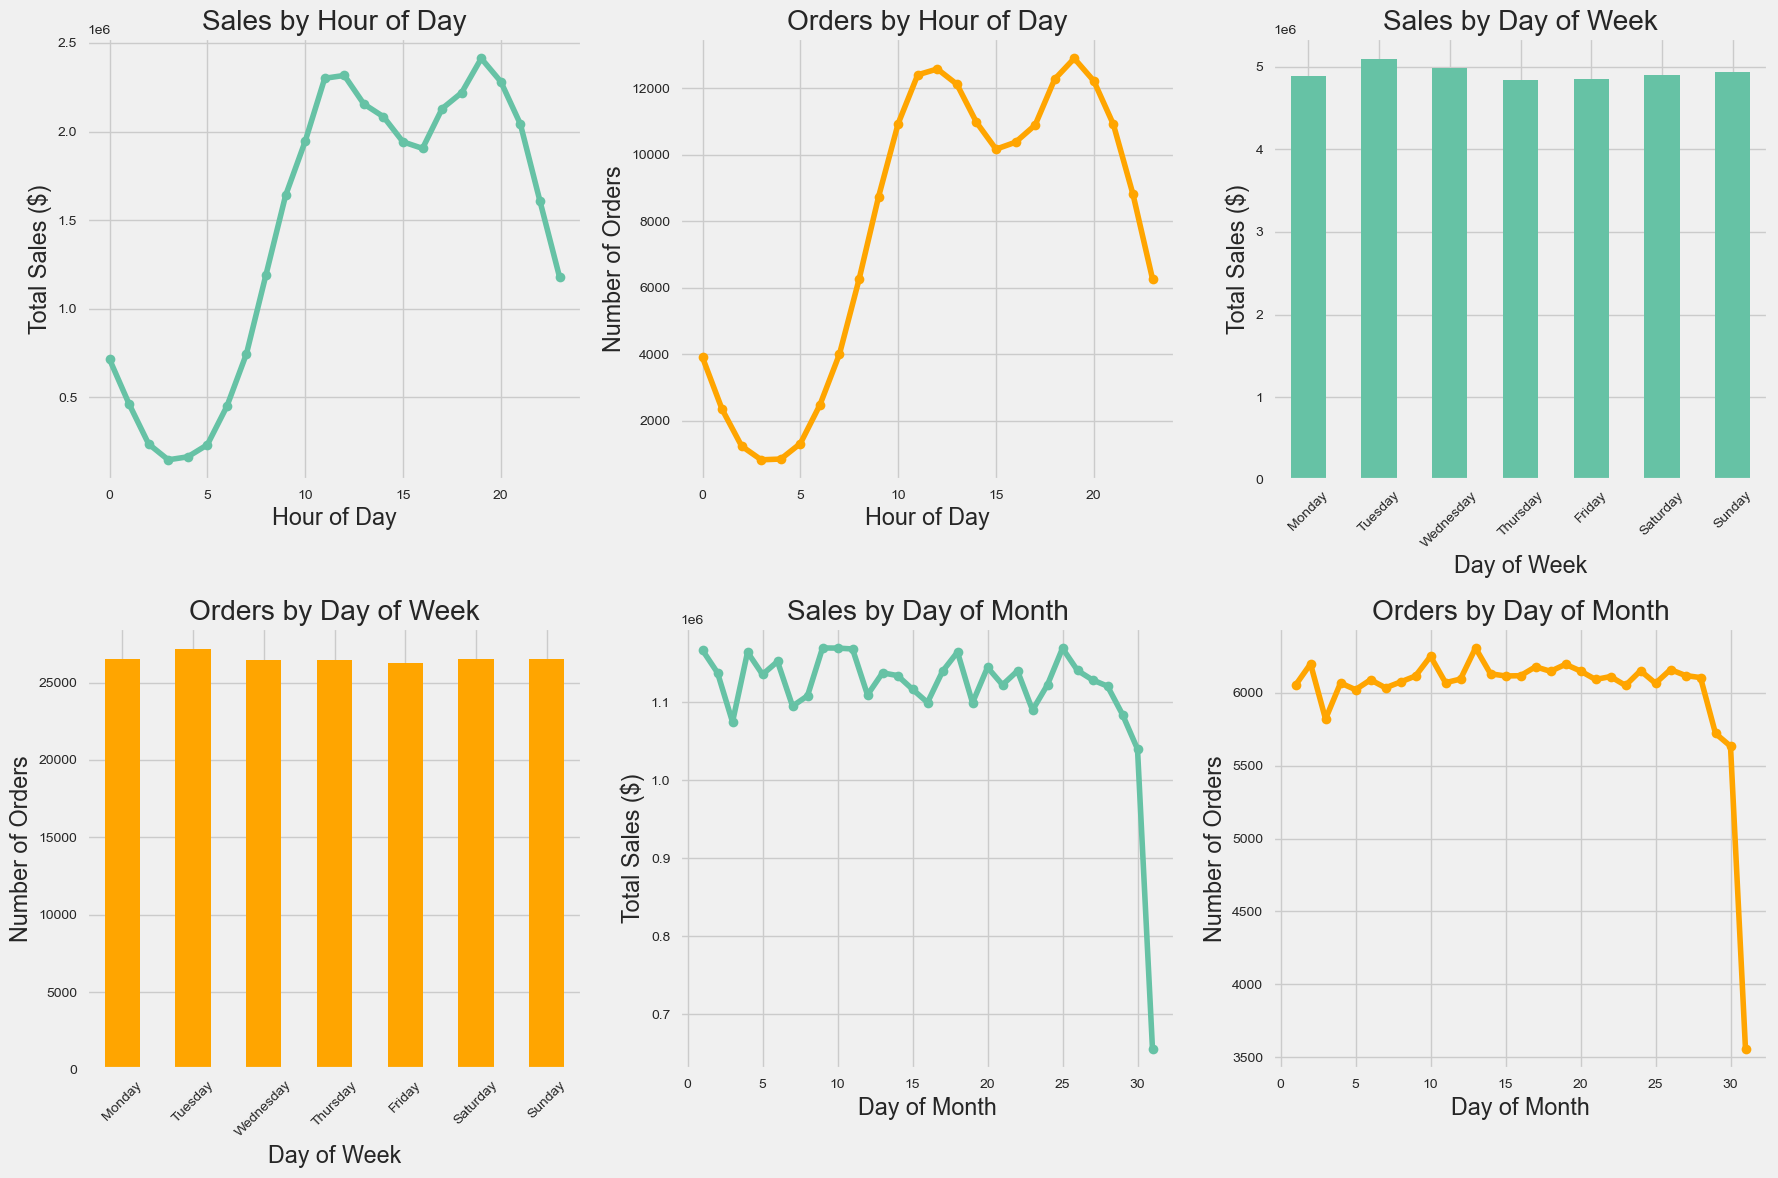

In [11]:
# 4.4 Time-Based Analysis

# Sales by hour of day
hourly_sales = df.groupby('Hour').agg({
    'Sales': 'sum',
    'Order ID': 'count'
}).rename(columns={'Order ID': 'Order Count'})

# Sales by day of week
df['Day_of_Week_Num'] = df['Order Date'].dt.dayofweek
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_sales = df.groupby('Day_of_Week').agg({
    'Sales': 'sum',
    'Order ID': 'count'
}).rename(columns={'Order ID': 'Order Count'})
daily_sales = daily_sales.reindex(day_order)

# Sales by day of month
daily_sales_month = df.groupby('Day').agg({
    'Sales': 'sum',
    'Order ID': 'count'
}).rename(columns={'Order ID': 'Order Count'})

# Visualization
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
hourly_sales['Sales'].plot(kind='line', marker='o')
plt.title('Sales by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Total Sales ($)')
plt.grid(True)

plt.subplot(2, 3, 2)
hourly_sales['Order Count'].plot(kind='line', marker='o', color='orange')
plt.title('Orders by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.grid(True)

plt.subplot(2, 3, 3)
daily_sales['Sales'].plot(kind='bar')
plt.title('Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)

plt.subplot(2, 3, 4)
daily_sales['Order Count'].plot(kind='bar', color='orange')
plt.title('Orders by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

plt.subplot(2, 3, 5)
daily_sales_month['Sales'].plot(kind='line', marker='o')
plt.title('Sales by Day of Month')
plt.xlabel('Day of Month')
plt.ylabel('Total Sales ($)')
plt.grid(True)

plt.subplot(2, 3, 6)
daily_sales_month['Order Count'].plot(kind='line', marker='o', color='orange')
plt.title('Orders by Day of Month')
plt.xlabel('Day of Month')
plt.ylabel('Number of Orders')
plt.grid(True)

plt.tight_layout()
plt.show()


# Analyze sales patterns across different time dimensions
# Identify peak hours, days, and periods for sales
# Help in resource planning and marketing timing

Top 10 Product Pairs Frequently Bought Together:
Lightning Charging Cable & iPhone: 1015 times
Google Phone & USB-C Charging Cable: 999 times
Wired Headphones & iPhone: 462 times
Google Phone & Wired Headphones: 423 times
Apple Airpods Headphones & iPhone: 373 times
USB-C Charging Cable & Vareebadd Phone: 368 times
Bose SoundSport Headphones & Google Phone: 228 times
USB-C Charging Cable & Wired Headphones: 205 times
Vareebadd Phone & Wired Headphones: 149 times
Lightning Charging Cable & Wired Headphones: 129 times


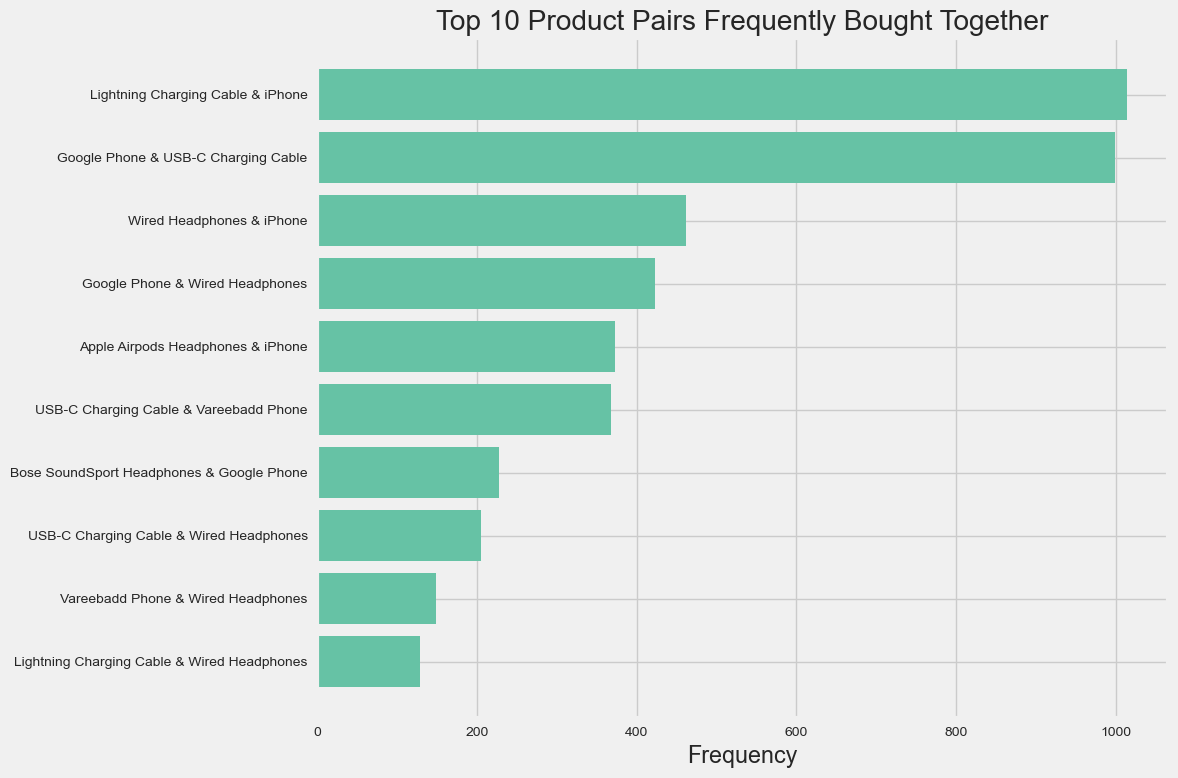

In [12]:
# 4.5 Product Pair Analysis (What products are often bought together)

# Find products frequently bought together
from itertools import combinations
from collections import Counter

# Group by Order ID to see what products were bought together
order_group = df.groupby('Order ID')['Product'].apply(list)

# Find combinations of products within each order
product_pairs = []
for products in order_group:
    if len(products) > 1:
        # Get all possible pairs of products in the order
        pairs = list(combinations(sorted(products), 2))
        product_pairs.extend(pairs)

# Count frequency of each pair
pair_counts = Counter(product_pairs)

# Get top 10 most common pairs
top_pairs = pair_counts.most_common(10)

print("Top 10 Product Pairs Frequently Bought Together:")
for pair, count in top_pairs:
    print(f"{pair[0]} & {pair[1]}: {count} times")

# Visualization
pairs_df = pd.DataFrame(top_pairs, columns=['Product Pair', 'Frequency'])
pairs_df['Pair_Names'] = pairs_df['Product Pair'].apply(lambda x: f"{x[0]} & {x[1]}")

plt.figure(figsize=(12, 8))
plt.barh(pairs_df['Pair_Names'], pairs_df['Frequency'])
plt.xlabel('Frequency')
plt.title('Top 10 Product Pairs Frequently Bought Together')
plt.gca().invert_yaxis()  # Display highest frequency at top
plt.tight_layout()
plt.show()


# Identify products that are frequently purchased together
# Useful for cross-selling strategies and product placement
# Helps in creating bundled offers


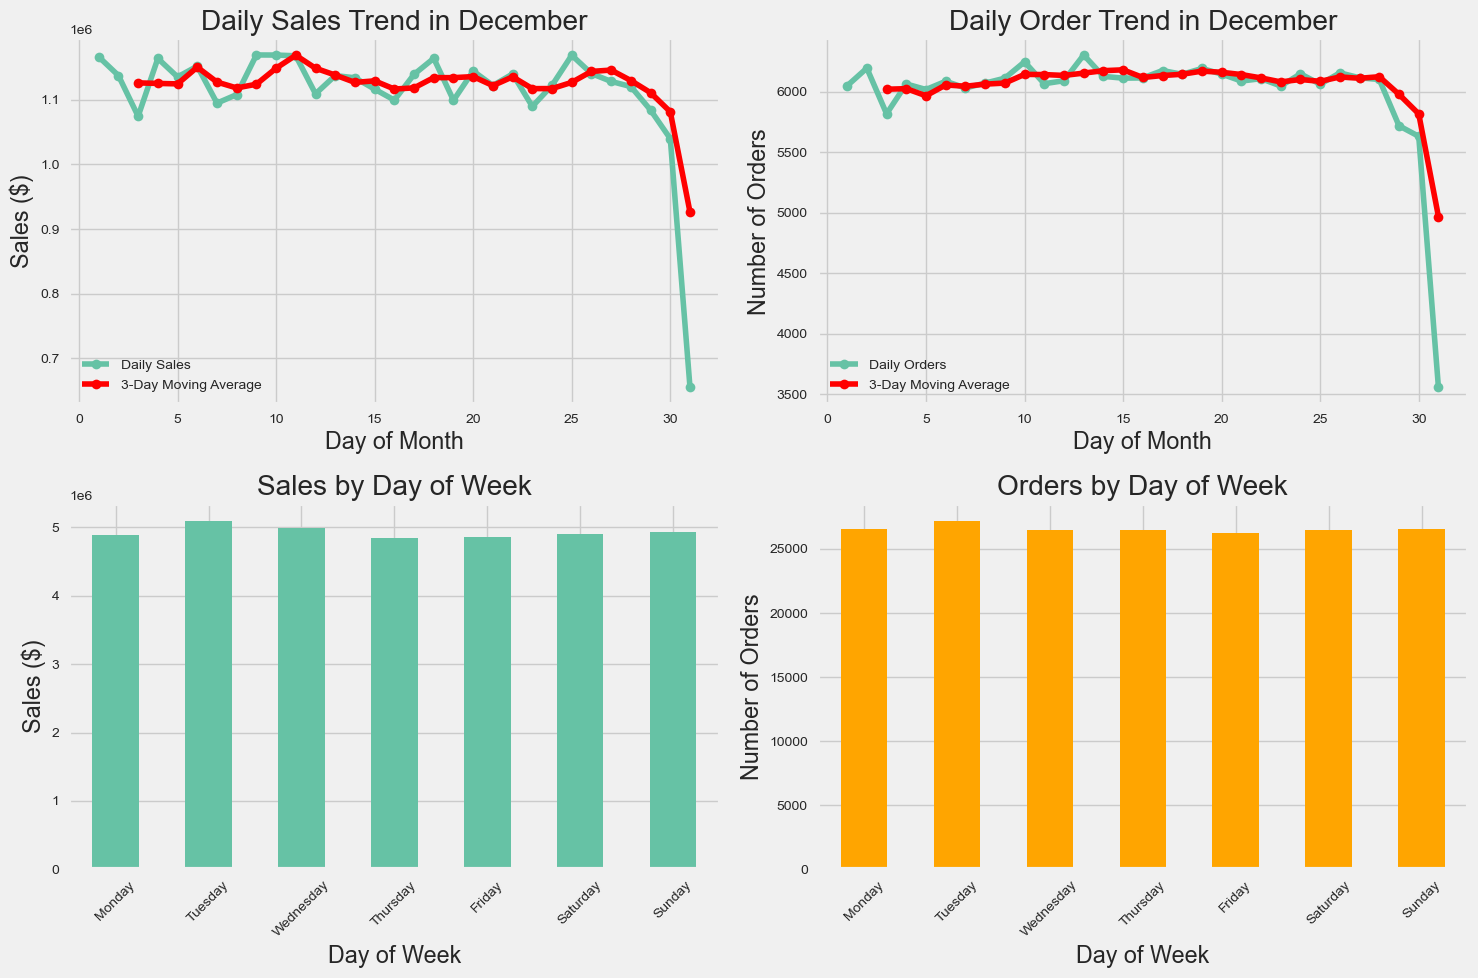

In [13]:
# 5: Advanced Analysis
     # 5.1 Monthly Sales Trend


# Since all data is from December, let's analyze daily trends within the month
daily_trend = df.groupby('Day').agg({
    'Sales': 'sum',
    'Order ID': 'count',
    'Quantity Ordered': 'sum'
}).rename(columns={'Order ID': 'Order Count'})

# Calculate moving averages for smoother trend visualization
daily_trend['Sales_MA_3'] = daily_trend['Sales'].rolling(window=3).mean()
daily_trend['Orders_MA_3'] = daily_trend['Order Count'].rolling(window=3).mean()

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(daily_trend.index, daily_trend['Sales'], marker='o', label='Daily Sales')
plt.plot(daily_trend.index, daily_trend['Sales_MA_3'], marker='o', label='3-Day Moving Average', color='red')
plt.title('Daily Sales Trend in December')
plt.xlabel('Day of Month')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(daily_trend.index, daily_trend['Order Count'], marker='o', label='Daily Orders')
plt.plot(daily_trend.index, daily_trend['Orders_MA_3'], marker='o', label='3-Day Moving Average', color='red')
plt.title('Daily Order Trend in December')
plt.xlabel('Day of Month')
plt.ylabel('Number of Orders')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
# Weekly pattern (group by day of week)
day_of_week_sales = df.groupby('Day_of_Week_Num').agg({
    'Sales': 'sum',
    'Order ID': 'count'
}).rename(columns={'Order ID': 'Order Count'})
day_of_week_sales.index = day_order

day_of_week_sales['Sales'].plot(kind='bar')
plt.title('Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)

plt.subplot(2, 2, 4)
day_of_week_sales['Order Count'].plot(kind='bar', color='orange')
plt.title('Orders by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# Analyze daily sales trends with moving averages for smoother visualization
# Identify weekly patterns in customer purchasing behavior
# Help in forecasting and inventory management

Customer Segmentation Analysis:
              Sales                          Quantity Ordered Product Count
              count          sum        mean             mean          mean
Segment                                                                    
High Value    41943  28408845.59  677.320306         1.150752      1.132322
Low Value     97510   1013886.98   10.397774         1.236396      1.010789
Medium Value  38984   5069303.40  130.035486         1.032526      1.023369


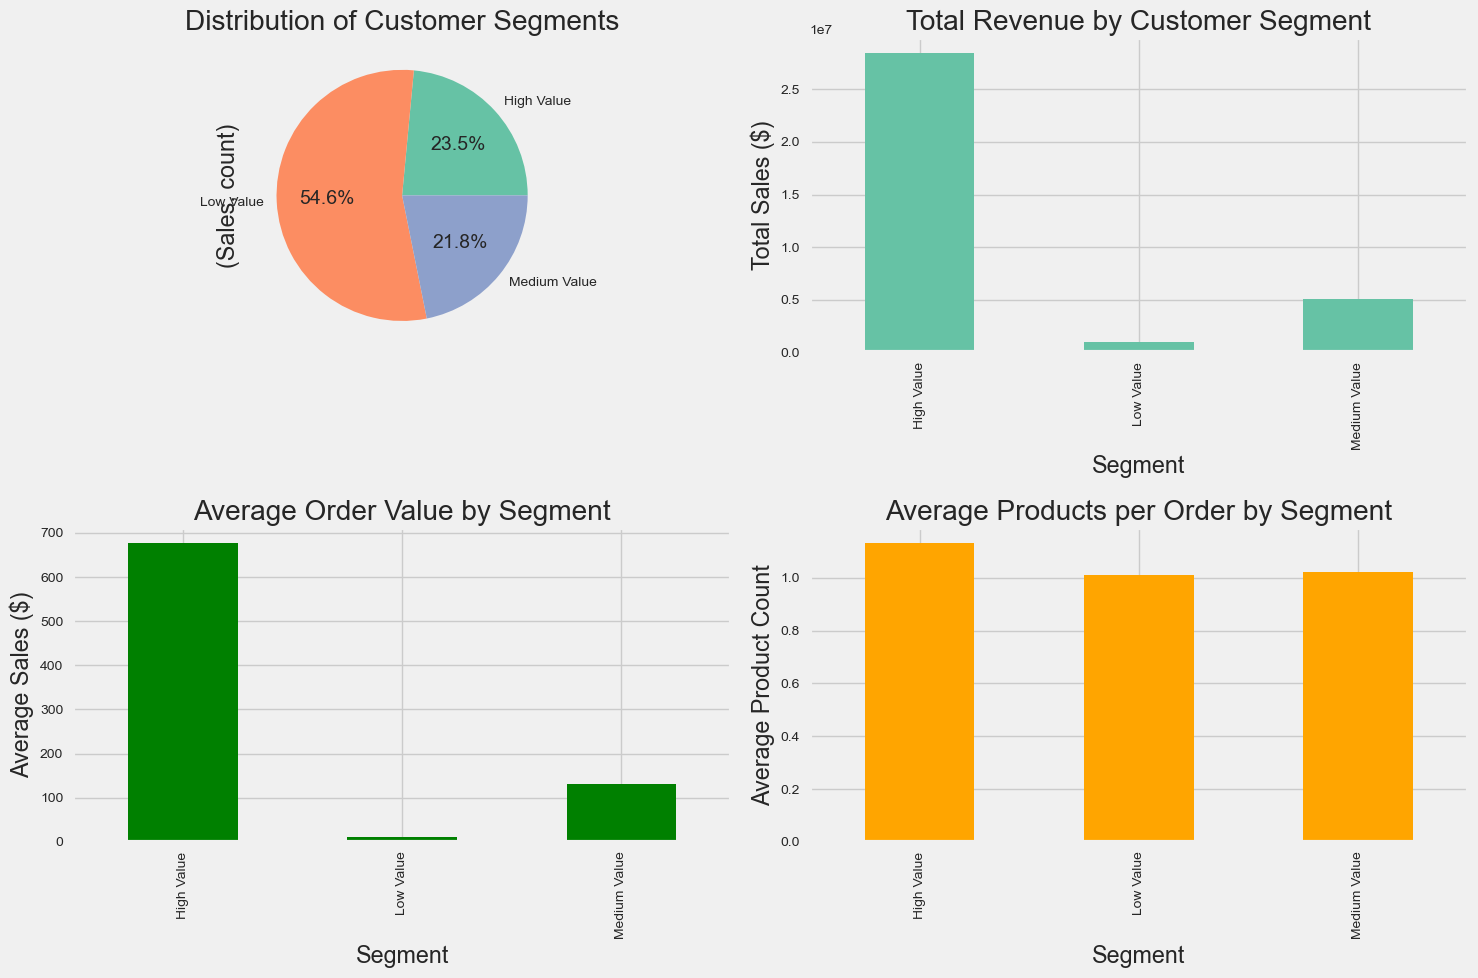

In [14]:
# 5.2 Customer Segmentation by Purchase Behavior

# Analyze order patterns (assuming each order ID represents a customer transaction)
order_analysis = df.groupby('Order ID').agg({
    'Sales': 'sum',
    'Quantity Ordered': 'sum',
    'Product': 'count'
}).rename(columns={'Product': 'Product Count'})

# Create customer segments based on order value
def segment_customers(order_value):
    if order_value < 50:
        return 'Low Value'
    elif order_value < 200:
        return 'Medium Value'
    else:
        return 'High Value'

order_analysis['Segment'] = order_analysis['Sales'].apply(segment_customers)

segment_summary = order_analysis.groupby('Segment').agg({
    'Sales': ['count', 'sum', 'mean'],
    'Quantity Ordered': 'mean',
    'Product Count': 'mean'
})

print("Customer Segmentation Analysis:")
print(segment_summary)

# Visualization
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
segment_summary[('Sales', 'count')].plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of Customer Segments')

plt.subplot(2, 2, 2)
segment_summary[('Sales', 'sum')].plot(kind='bar')
plt.title('Total Revenue by Customer Segment')
plt.ylabel('Total Sales ($)')

plt.subplot(2, 2, 3)
segment_summary[('Sales', 'mean')].plot(kind='bar', color='green')
plt.title('Average Order Value by Segment')
plt.ylabel('Average Sales ($)')

plt.subplot(2, 2, 4)
segment_summary[('Product Count', 'mean')].plot(kind='bar', color='orange')
plt.title('Average Products per Order by Segment')
plt.ylabel('Average Product Count')

plt.tight_layout()
plt.show()


# Segment customers based on their spending behavior
# Identify high-value customers for targeted marketing
# Understand different customer segments' purchasing patterns

In [15]:
# 6: Key Insights and Business Recommendations

# Generate key insights
print("="*50)
print("KEY BUSINESS INSIGHTS")
print("="*50)

# 1. Overall Performance
print(f"1. Total Revenue: ${total_sales:,.2f}")
print(f"2. Total Orders: {total_orders}")
print(f"3. Average Order Value: ${average_order_value:.2f}")

# 2. Top Performing Products
top_product = product_sales.index[0]
top_product_revenue = product_sales.iloc[0]['Sales']
print(f"4. Best Selling Product: {top_product} (${top_product_revenue:,.2f})")

# 3. Top Performing City
top_city = city_sales.index[0]
top_city_revenue = city_sales.iloc[0]['Sales']
print(f"5. Highest Revenue City: {top_city} (${top_city_revenue:,.2f})")

# 4. Peak Sales Hour
peak_hour = hourly_sales['Sales'].idxmax()
peak_hour_sales = hourly_sales.loc[peak_hour, 'Sales']
print(f"6. Peak Sales Hour: {peak_hour}:00 (${peak_hour_sales:,.2f})")

# 5. Most Common Product Pair
if top_pairs:
    top_pair = top_pairs[0][0]
    top_pair_count = top_pairs[0][1]
    print(f"7. Most Frequently Bought Together: {top_pair[0]} & {top_pair[1]} ({top_pair_count} times)")

print("\n" + "="*50)
print("BUSINESS RECOMMENDATIONS")
print("="*50)
print("1. Inventory Management: Stock more of high-selling products")
print("2. Marketing Focus: Target top-performing cities with promotions")
print("3. Staffing: Schedule more staff during peak hours (7 PM)")
print("4. Bundling: Create product bundles for frequently paired items")
print("5. Pricing Strategy: Analyze price sensitivity of medium-value customers")
print("6. Expansion: Consider opening new stores in high-performing cities")



# Summarize the most important findings from our analysis
# Translate data insights into actionable business recommendations
# Provide clear guidance for decision-making

KEY BUSINESS INSIGHTS
1. Total Revenue: $34,492,035.97
2. Total Orders: 178437
3. Average Order Value: $193.30
4. Best Selling Product: Macbook Pro Laptop ($8,037,600.00)
5. Highest Revenue City:  San Francisco ($8,262,203.91)
6. Peak Sales Hour: 19:00 ($2,412,938.54)
7. Most Frequently Bought Together: Lightning Charging Cable & iPhone (1015 times)

BUSINESS RECOMMENDATIONS
1. Inventory Management: Stock more of high-selling products
2. Marketing Focus: Target top-performing cities with promotions
3. Staffing: Schedule more staff during peak hours (7 PM)
4. Bundling: Create product bundles for frequently paired items
5. Pricing Strategy: Analyze price sensitivity of medium-value customers
6. Expansion: Consider opening new stores in high-performing cities


In [16]:
# 7: Export Results

# Create a summary dataframe for export
summary_data = {
    'Metric': ['Total Revenue', 'Total Orders', 'Average Order Value', 
               'Top Product', 'Top City', 'Peak Hour'],
    'Value': [total_sales, total_orders, average_order_value, 
              top_product, top_city, f"{peak_hour}:00"]
}

summary_df = pd.DataFrame(summary_data)

# Export to CSV
summary_df.to_csv('sales_analysis_summary.csv', index=False)
product_sales.to_csv('product_performance.csv')
city_sales.to_csv('city_performance.csv')

print("Analysis results exported to CSV files")

Analysis results exported to CSV files


In [ ]:
# Project Summary
# This comprehensive sales data analysis project demonstrates how to:
# Load and clean real-world sales data
# Perform exploratory data analysis to understand patterns
# Visualize insights using various chart types
# Extract business intelligence from raw data
# Generate actionable recommendations